In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "I love programming"

tokens = tokenizer.tokenize(text)

print(tokens)

['i', 'love', 'programming']


In [ ]:
text = "I am learning artificial intelligence"
print(tokenizer.tokenize(text))

['i', 'am', 'learning', 'artificial', 'intelligence']


In [ ]:
text = "unbelievable"
print(tokenizer.tokenize(text))

['unbelievable']


In [ ]:
from transformers import  AutoModel
import torch

model = AutoModel.from_pretrained("bert-base-uncased")

text = "I deposited money in the bank."

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.last_hidden_state.shape)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 9, 768])


In [ ]:
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

sentences = [
    "I deposited money in the bank.",
    "The boat reached the bank of the river."
]

bank_vectors = []

for sentence in sentences:

    inputs = tokenizer(sentence, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    bank_index = tokens.index("bank")

    bank_vector = outputs.last_hidden_state[
        0,
        bank_index
    ]

    bank_vectors.append(
        bank_vector.numpy()
    )

similarity = cosine_similarity(
    [bank_vectors[0]],
    [bank_vectors[1]]
)

print("Bank similarity:", similarity[0][0])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bank similarity: 0.5033637


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "I love programming"

tokens = tokenizer.tokenize(text)

print(tokens)

['i', 'love', 'programming']


In [ ]:
tokens = tokenizer.tokenize("unbelievable")
print(tokens)

['unbelievable']


In [ ]:
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Tokens:", tokens)
print('IDs:', token_ids)

Tokens: ['unbelievable']
IDs: [23653]


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

model = AutoModel.from_pretrained('bert-base-uncased')

text = "I love Python"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
  outputs = model(**inputs)

vectors = outputs.last_hidden_state

print(outputs.last_hidden_state.shape)

python_vector = vectors[0][3]

print(python_vector)
print(python_vector.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 5, 768])
tensor([-5.6757e-01, -1.4752e-01, -1.1502e-01,  1.1064e-01,  5.3833e-02,
        -7.2471e-03, -9.2612e-02,  4.3837e-01, -1.6650e-01, -4.7298e-02,
        -7.5674e-01, -6.4194e-02,  1.4203e-01,  5.8976e-01, -2.4138e-01,
         9.8960e-02,  2.9367e-01,  5.7472e-01, -2.9454e-01,  2.8409e-01,
        -3.4463e-02, -1.1155e-01, -4.9234e-02, -4.2545e-01, -2.6622e-01,
         3.8268e-01,  5.1369e-02, -1.4505e-01,  2.5700e-01,  2.7371e-01,
         3.9169e-02,  1.7476e-01,  6.1750e-01,  7.5443e-01, -1.7581e-01,
        -4.0271e-01,  9.0453e-03,  2.6237e-01, -2.5076e-01, -1.8467e-01,
         8.5590e-01, -1.4811e-01,  1.9091e-01, -9.5045e-01,  4.0754e-02,
        -1.2321e-01, -1.4158e-01, -3.6206e-01,  2.4935e-01, -2.1504e-01,
        -3.7461e-01,  1.6647e-01, -5.3707e-01,  4.2805e-01,  9.3948e-02,
        -5.0052e-01,  2.2928e-01,  2.4187e-01, -5.2525e-01, -2.2248e-01,
         4.2347e-01, -3.2930e-01,  3.0119e-01,  1.1102e-01, -2.3238e-02,
         2.1346e-01,  5.930

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
import numpy as np

word1 = np.array([[1,2,3]])
word2 = np.array([[1,2,3]])

similarity = cosine_similarity(word1, word2)

similarity

array([[1.]])

In [ ]:
word2 = np.array([[1,2,2,]])

similarity = cosine_similarity(word1, word2)

similarity

array([[0.97995789]])

In [ ]:
word2 = np.array([[-1,-2,-3]])

cosine_similarity(word1, word2)

array([[-1.]])

In [ ]:
pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer


model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = ['I love Python', 'Python is my favourite programming language']

embeddings = model.encode(sentences)

print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(2, 384)


In [ ]:
similarity = cosine_similarity([embeddings[0], embeddings[1]])

In [ ]:
similarity

array([[1.0000001, 0.8953722],
       [0.8953722, 1.       ]], dtype=float32)

In [ ]:
sentences = ['I love programming',
             "I enjoy writing code",
             "The weather is very cold today",
             "A dog is running in the park"]

embeddings = model.encode(sentences)

similarity = cosine_similarity(embeddings)

similarity

array([[ 1.0000001 ,  0.7146444 , -0.0217908 ,  0.09266143],
       [ 0.7146444 ,  1.        ,  0.02958521,  0.06221351],
       [-0.0217908 ,  0.02958521,  0.9999998 ,  0.04374347],
       [ 0.09266143,  0.06221351,  0.04374347,  1.        ]],
      dtype=float32)

In [ ]:
pip install gensim

In [ ]:
from gensim.models import KeyedVectors

model = KeyedVectors.load_word2vec_format(
    "GoogleNews-vectors-negative300.bin",
    binary=True
)


model['King']

FileNotFoundError: [Errno 2] No such file or directory: 'GoogleNews-vectors-negative300.bin'

In [ ]:
import torch
sentences = ['I deposited money in the bank.', "The boat reached the bank of the river."]


for sentence in sentences:
  inputs = tokenizer(sentence, return_tensors="pt")
  with torch.no_grad():
    outputs = model(**inputs)

  tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])


  print("\n sentence")
  print(sentence)

  print("\nTokens")
  print(tokens)

TypeError: BaseModel.forward() missing 1 required positional argument: 'input'

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

sentences = [
    "I deposited money in the bank.",
    "The boat reached the bank of the river."
]

for sentence in sentences:

    inputs = tokenizer(sentence, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    print("\nSentence:")
    print(sentence)

    print("\nTokens:")
    print(tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Sentence:
I deposited money in the bank.

Tokens:
['[CLS]', 'i', 'deposited', 'money', 'in', 'the', 'bank', '.', '[SEP]']

Sentence:
The boat reached the bank of the river.

Tokens:
['[CLS]', 'the', 'boat', 'reached', 'the', 'bank', 'of', 'the', 'river', '.', '[SEP]']


In [ ]:
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

sentences = ['I deposited money in the bank', "The boat reached the bank of the river"]

bank_vectors = []

for sentence in sentences:
  input = tokenizer(sentence, return_tensors="pt")

  with torch.no_grad():
    outputs = model(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])


    bank_index = tokens.index('bank')

    bank_vector = outputs.last_hidden_state[0, bank_index]

    bank_vectors.append(bank_vector.numpy())

similarity = cosine_similarity([bank_vectors[0]], [bank_vectors[1]])

print('Bank SImilarity:' ,similarity[0][0])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bank SImilarity: 1.0


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

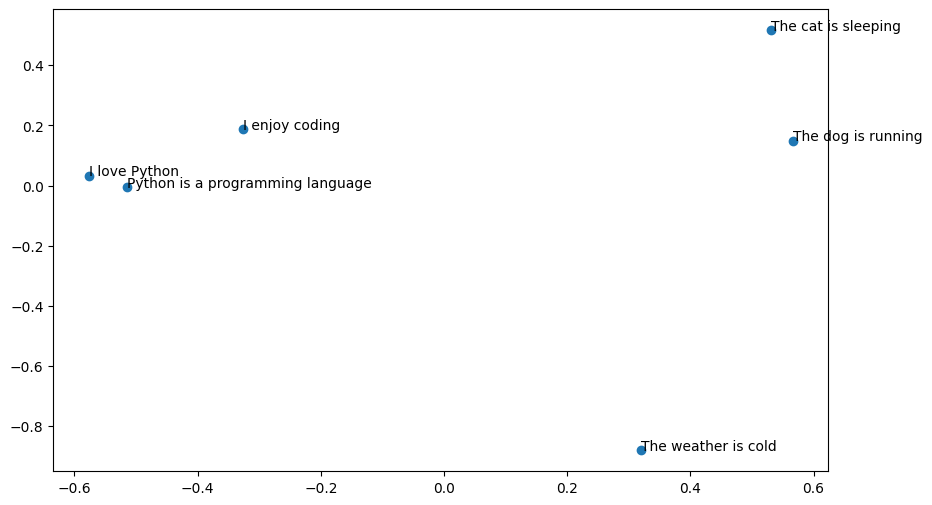

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = SentenceTransformer("all-MiniLM-L6-v2")


sentences = ['I love Python', "Python is a programming language", "I enjoy coding", "The dog is running", "The cat is sleeping" , "The weather is cold"]

embeddings = model.encode(sentences)

pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))

plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sentence in enumerate(sentences):
  plt.annotate(sentence, (reduced[i,0], reduced[i,1]))

plt.show()

In [ ]:
documents = [
    "Python is a programming language.",
    "FastAPI is a Python web framework.",
    "PostgreSQL is a relational database.",
    "React is a JavaScript frontend library.",
    "Docker is used for containerization."
]

In [ ]:
document_embeddings = model.encode(documents)

In [ ]:
query = "How can I create an API using python"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, document_embeddings)[0]
scores

array([0.48632938, 0.47333091, 0.08767225, 0.11975867, 0.01046876],
      dtype=float32)

In [ ]:
best_index = scores.argmax()

print(documents[best_index])

Python is a programming language.


In [ ]:
words = ['king','queen',"man",'woman','banana', 'computer']

embeddings = model.encode(words)

similarity = cosine_similarity(embeddings)

print(similarity)

[[0.9999999  0.68071264 0.32164574 0.26399505 0.39500815 0.37376177]
 [0.68071264 1.0000002  0.25411743 0.4393993  0.39658785 0.3626719 ]
 [0.32164574 0.25411743 0.9999997  0.3256784  0.24369904 0.24137835]
 [0.26399505 0.4393993  0.3256784  0.9999999  0.30242363 0.3139618 ]
 [0.39500815 0.39658785 0.24369904 0.30242363 1.0000001  0.396178  ]
 [0.37376177 0.3626719  0.24137835 0.3139618  0.396178   1.0000001 ]]


In [ ]:
for word, vector in zip(words, embeddings):
  print(word)
  print(vector[:10])
  print()

king
[-0.05959934  0.0505124  -0.06951012  0.07968026 -0.0467477   0.00098881
  0.07904329 -0.01273937  0.05839583 -0.03140246]

queen
[ 0.03548701 -0.06560464 -0.00993493  0.03159034 -0.01338688  0.02889187
  0.11670842 -0.03430928  0.05440544 -0.00558283]

man
[-0.10967567  0.04374184 -0.02631919 -0.02932639  0.02155486 -0.08548573
  0.1137282  -0.0682471  -0.01101972 -0.04662977]

woman
[-0.04559171  0.0113346  -0.01911309  0.04438019 -0.04691952  0.02770835
  0.11341317 -0.00598332  0.03175857 -0.00626809]

banana
[-5.43115959e-02  1.40455887e-02 -2.48163156e-02  2.68782545e-02
 -7.11777175e-05  3.38811688e-02  1.03280574e-01  5.13063520e-02
  2.06701644e-02  5.11332229e-02]

computer
[-0.05127363  0.04783837 -0.00333904 -0.03887025 -0.03269714 -0.03285833
  0.09360431  0.03932319  0.08196711  0.01824837]



Original embedding shape: (8, 384)
2D shape: (8, 2)


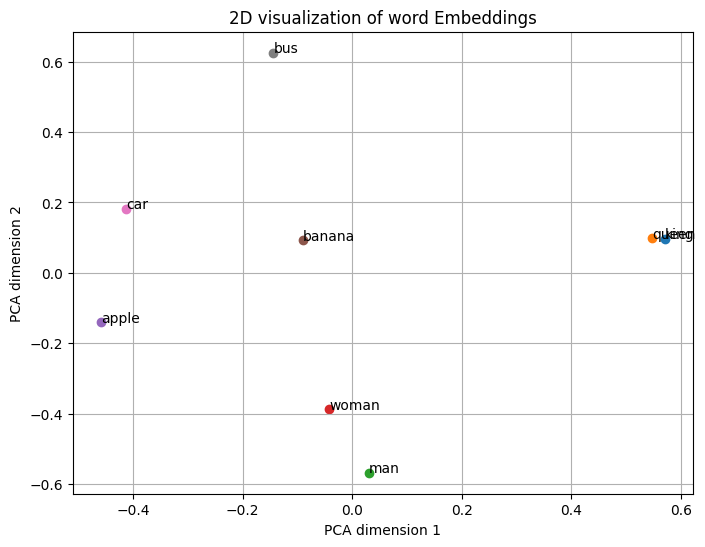

In [ ]:
words = ['king', 'queen', 'man','woman','apple','banana','car','bus']

embeddings = model.encode(words)

print("Original embedding shape:", embeddings.shape)

pca = PCA(n_components=2)

points = pca.fit_transform(embeddings)

print("2D shape:", points.shape)

plt.figure(figsize=(8,6))

for word, point in zip(words, points):
  x = point[0]
  y = point[1]

  plt.scatter(x,y)
  plt.annotate(word, (x,y))

plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.title("2D visualization of word Embeddings")
plt.grid()
plt.show()